In [ ]:
!pip install ucimlrepo

In [ ]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 9.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=2178143 sha256=9d965d53773ced5ceba9255b59f47c5d9402407494a0c948d972ad4b38749bd4
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [ ]:
!pip install numpy==1.26.0

# ***K-Means Clustering of Iris Dataset***


K-Means CLuster Centers:
[[5.6826087  2.6826087  4.16086957 1.30434783]
 [5.25555556 3.67037037 1.5037037  0.28888889]
 [6.56818182 3.08636364 5.53636364 2.16363636]
 [6.02777778 2.73333333 5.02777778 1.79444444]
 [5.24285714 2.37142857 3.44285714 1.02857143]
 [7.475      3.125      6.3        2.05      ]
 [6.45       3.01666667 4.60555556 1.43888889]
 [4.71304348 3.12173913 1.4173913  0.19130435]]
Cluster Labels:
[1 7 7 7 1 1 7 1 7 7]


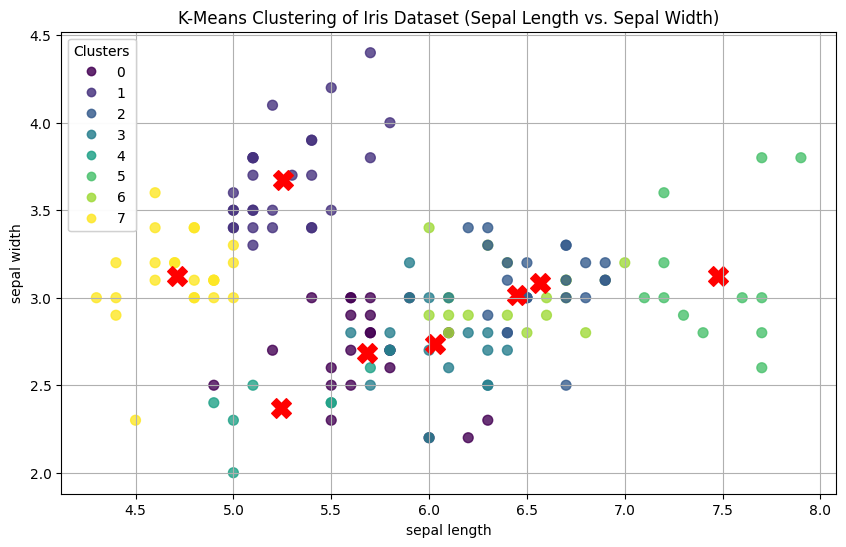

In [ ]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features

# Convert the pandas DataFrame of features to a NumPy array for scikit-learn
# K-Means can handle the DataFrame directly, but conversion is often a good practice
# and matches the style of the original example.
X_df = X.values

# --- K-Means Clustering on Iris Data ---
# Instantiate the KMeans model. Iris has 3 species, so k=3 is the natural choice.
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

# Fit the model to the Iris feature data
kmeans.fit(X_df)

# Get the cluster labels for each data point
labels = kmeans.predict(X_df)

# Get the coordinates of the cluster centers
centroids = kmeans.cluster_centers_

# --- Visualization (using the first two features: Sepal Length and Sepal Width) ---
# For visualization, we select the first two features (column indices 0 and 1)
# which are Sepal Length and Sepal Width, as K-Means works in 4D, but we plot in 2D.

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Plot the data points, colored by their assigned cluster label
# X[:, 0] is Sepal Length, X[:, 1] is Sepal Width
scatter = plt.scatter(X_df[:, 0], X_df[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)

# Plot the cluster centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

print("K-Means CLuster Centers:")
print(kmeans.cluster_centers_)

print("Cluster Labels:")
print(kmeans.labels_[:10])

# Add a legend for the clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.title('K-Means Clustering of Iris Dataset (Sepal Length vs. Sepal Width)')
plt.xlabel(X.columns[0]) # Sepal Length
plt.ylabel(X.columns[1]) # Sepal Width
plt.grid(True)
plt.show()

# ***K-Medoids Clustering of Iris Dataset***

K-Medoids Cluster Medoids (Centers):
[[7.1 3.  5.9 2.1]
 [5.  3.3 1.4 0.2]
 [5.6 2.5 3.9 1.1]
 [6.3 2.5 4.9 1.5]
 [5.8 2.7 5.1 1.9]
 [6.1 3.  4.6 1.4]
 [6.5 3.  5.2 2. ]
 [5.3 3.7 1.5 0.2]]

Cluster Labels (First 10):
[1 1 1 1 1 7 1 1 1 1]


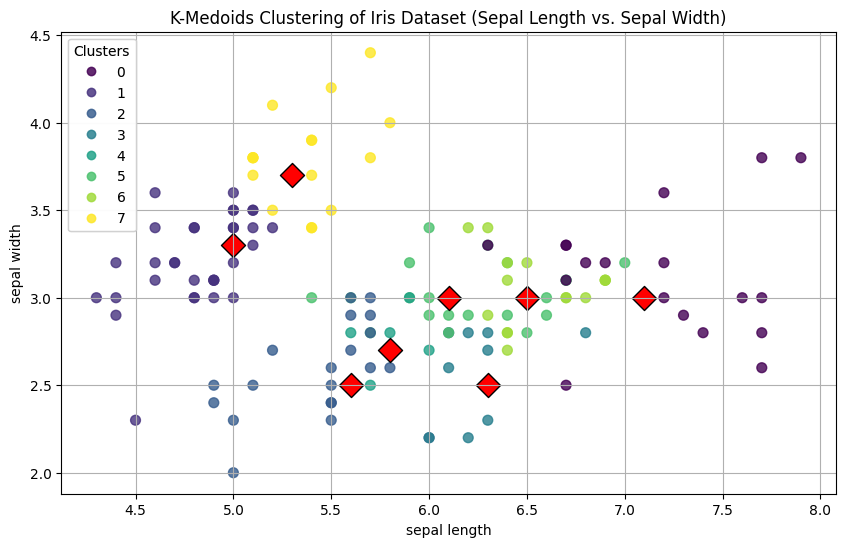

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Import pandas to handle dataframes
from ucimlrepo import fetch_ucirepo
from sklearn_extra.cluster import KMedoids # KMedoids is from sklearn_extra

# --- 1. Fetch and Prepare Iris Data ---
iris = fetch_ucirepo(id=53)

# X is the pandas DataFrame of features (Sepal Length, Sepal Width, etc.)
X = iris.data.features

# Convert the pandas DataFrame of features to a NumPy array for fitting
X_array = X.values

# --- 2. K-Medoids Clustering on Iris Data ---
# Instantiate the KMedoids model. Iris has 3 species, so k=3 is the natural choice.
kmedoids = KMedoids(n_clusters=8, random_state=42, init='k-medoids++')

# Fit the model to the Iris feature data
kmedoids.fit(X_array)

# Get the cluster labels for each data point
labels = kmedoids.predict(X_array)

# Get the coordinates of the cluster medoids (cluster centers)
medoids = kmedoids.cluster_centers_

# --- 3. Output Results ---
print("K-Medoids Cluster Medoids (Centers):")
# The medoids are actual data points from the dataset
print(medoids)

print("\nCluster Labels (First 10):")
print(kmedoids.labels_[:10])

# --- 4. Visualization (using the first two features: Sepal Length and Sepal Width) ---
# Create the scatter plot
plt.figure(figsize=(10, 6))

# Plot the data points, colored by their assigned cluster label
# X_array[:, 0] is Sepal Length, X_array[:, 1] is Sepal Width
scatter = plt.scatter(X_array[:, 0], X_array[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)

# Plot the cluster medoids
plt.scatter(medoids[:, 0], medoids[:, 1], c='red', s=150, marker='D', edgecolor='black', label='Medoids') # Using 'D' for a distinct diamond shape

# Add a legend for the clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

# Add plot labels using the column names from the original DataFrame X
plt.title('K-Medoids Clustering of Iris Dataset (Sepal Length vs. Sepal Width)')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.grid(True)
plt.show()

# ***K-Means Clustering of Wine Dataset***

K-Means CLuster Centers:
[[1.37512500e+01 1.96916667e+00 2.34875000e+00 1.69750000e+01
  1.05041667e+02 2.79458333e+00 2.92166667e+00 2.72500000e-01
  1.89541667e+00 5.16833333e+00 1.05750000e+00 3.18916667e+00
  1.05770833e+03]
 [1.25490323e+01 2.34258065e+00 2.32774194e+00 2.08645161e+01
  9.30645161e+01 1.89290323e+00 1.60741935e+00 4.12903226e-01
  1.33709677e+00 4.67645158e+00 9.02258065e-01 2.35806452e+00
  4.89129032e+02]
 [1.41366667e+01 1.83166667e+00 2.41166667e+00 1.62666667e+01
  1.07666667e+02 3.25500000e+00 3.49333333e+00 2.71666667e-01
  2.21666667e+00 7.23333333e+00 1.11333333e+00 3.02833333e+00
  1.53033333e+03]
 [1.30281250e+01 2.33500000e+00 2.44875000e+00 1.97312500e+01
  1.12125000e+02 2.32875000e+00 1.99687500e+00 3.52500000e-01
  1.71062500e+00 5.35250000e+00 9.11625000e-01 2.68312500e+00
  8.65500000e+02]
 [1.37623529e+01 1.78058824e+00 2.54058824e+00 1.73588235e+01
  1.05411765e+02 2.83294118e+00 2.97588235e+00 3.08235294e-01
  1.82352941e+00 5.91647059e+00 1.0

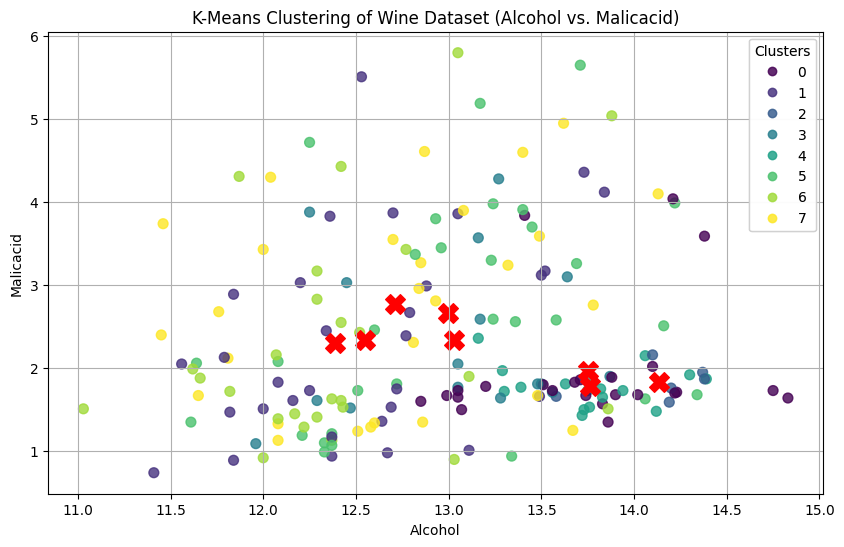

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
Xw = wine.data.features

# Convert the pandas DataFrame of features to a NumPy array for scikit-learn
# K-Means can handle the DataFrame directly, but conversion is often a good practice
# and matches the style of the original example.
Xw_df = Xw.values

# --- K-Means Clustering on Iris Data ---
# Instantiate the KMeans model. Iris has 3 species, so k=3 is the natural choice.
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

# Fit the model to the Iris feature data
kmeans.fit(Xw_df)

# Get the cluster labels for each data point
labels = kmeans.predict(Xw_df)

# Get the coordinates of the cluster centers
centroids = kmeans.cluster_centers_

# --- Visualization (using the first two features: Sepal Length and Sepal Width) ---
# For visualization, we select the first two features (column indices 0 and 1)
# which are Sepal Length and Sepal Width, as K-Means works in 4D, but we plot in 2D.

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Plot the data points, colored by their assigned cluster label
# X[:, 0] is Sepal Length, X[:, 1] is Sepal Width
scatter = plt.scatter(Xw_df[:, 0], Xw_df[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)

# Plot the cluster centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

print("K-Means CLuster Centers:")
print(kmeans.cluster_centers_)

print("Cluster Labels:")
print(kmeans.labels_[:10])

# Add a legend for the clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.title('K-Means Clustering of Wine Dataset (Alcohol vs. Malicacid)')
plt.xlabel(Xw.columns[0]) # Alcohol
plt.ylabel(Xw.columns[1]) # Malicacid
plt.grid(True)
plt.show()

# ***K-Medoids Clustering of Wine Dataset***

K-Medoids Cluster Medoids (Centers):
[[1.220e+01 3.030e+00 2.320e+00 1.900e+01 9.600e+01 1.250e+00 4.900e-01
  4.000e-01 7.300e-01 5.500e+00 6.600e-01 1.830e+00 5.100e+02]
 [1.410e+01 2.020e+00 2.400e+00 1.880e+01 1.030e+02 2.750e+00 2.920e+00
  3.200e-01 2.380e+00 6.200e+00 1.070e+00 2.750e+00 1.060e+03]
 [1.332e+01 3.240e+00 2.380e+00 2.150e+01 9.200e+01 1.930e+00 7.600e-01
  4.500e-01 1.250e+00 8.420e+00 5.500e-01 1.620e+00 6.500e+02]
 [1.358e+01 1.660e+00 2.360e+00 1.910e+01 1.060e+02 2.860e+00 3.190e+00
  2.200e-01 1.950e+00 6.900e+00 1.090e+00 2.880e+00 1.515e+03]
 [1.229e+01 1.610e+00 2.210e+00 2.040e+01 1.030e+02 1.100e+00 1.020e+00
  3.700e-01 1.460e+00 3.050e+00 9.060e-01 1.820e+00 8.700e+02]
 [1.329e+01 1.970e+00 2.680e+00 1.680e+01 1.020e+02 3.000e+00 3.230e+00
  3.100e-01 1.660e+00 6.000e+00 1.070e+00 2.840e+00 1.270e+03]
 [1.334e+01 9.400e-01 2.360e+00 1.700e+01 1.100e+02 2.530e+00 1.300e+00
  5.500e-01 4.200e-01 3.170e+00 1.020e+00 1.930e+00 7.500e+02]
 [1.207e+01 2.160e

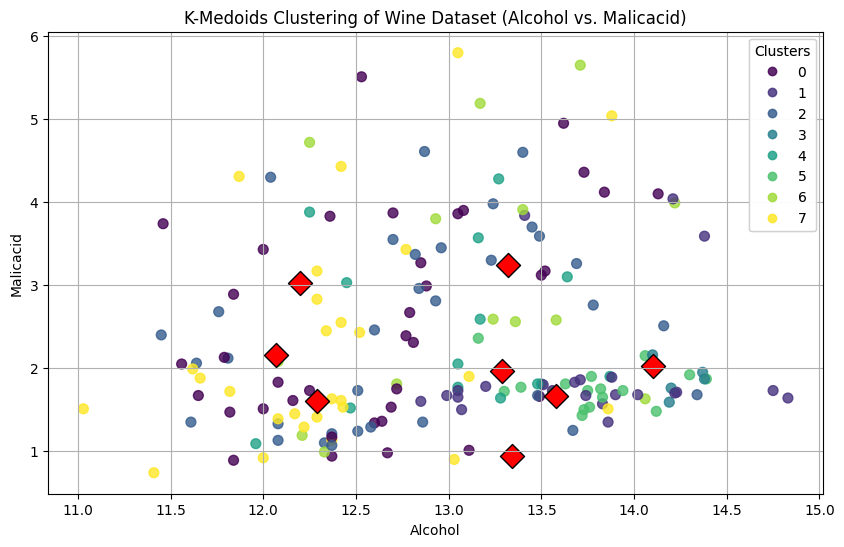

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Import pandas to handle dataframes
from ucimlrepo import fetch_ucirepo
from sklearn_extra.cluster import KMedoids # KMedoids is from sklearn_extra

# --- 1. Fetch and Prepare Iris Data ---
iris = fetch_ucirepo(id=53)

# X is the pandas DataFrame of features (Sepal Length, Sepal Width, etc.)
Xw = wine.data.features

# Convert the pandas DataFrame of features to a NumPy array for fitting
Xw_array = Xw.values

# --- 2. K-Medoids Clustering on Iris Data ---
# Instantiate the KMedoids model. Iris has 3 species, so k=3 is the natural choice.
kmedoids = KMedoids(n_clusters=8, random_state=42, init='k-medoids++')

# Fit the model to the Iris feature data
kmedoids.fit(Xw_array)

# Get the cluster labels for each data point
labels = kmedoids.predict(Xw_array)

# Get the coordinates of the cluster medoids (cluster centers)
medoids = kmedoids.cluster_centers_

# --- 3. Output Results ---
print("K-Medoids Cluster Medoids (Centers):")
# The medoids are actual data points from the dataset
print(medoids)

print("\nCluster Labels (First 10):")
print(kmedoids.labels_[:10])

# --- 4. Visualization (using the first two features: Sepal Length and Sepal Width) ---
# Create the scatter plot
plt.figure(figsize=(10, 6))

# Plot the data points, colored by their assigned cluster label
# X_array[:, 0] is Sepal Length, X_array[:, 1] is Sepal Width
scatter = plt.scatter(Xw_array[:, 0], Xw_array[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)

# Plot the cluster medoids
plt.scatter(medoids[:, 0], medoids[:, 1], c='red', s=150, marker='D', edgecolor='black', label='Medoids') # Using 'D' for a distinct diamond shape

# Add a legend for the clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

# Add plot labels using the column names from the original DataFrame X
plt.title('K-Medoids Clustering of Wine Dataset (Alcohol vs. Malicacid)')
plt.xlabel(Xw.columns[0])
plt.ylabel(Xw.columns[1])
plt.grid(True)
plt.show()

# ***Hierarchical Clustering Dendrogram of Iris Dataset***

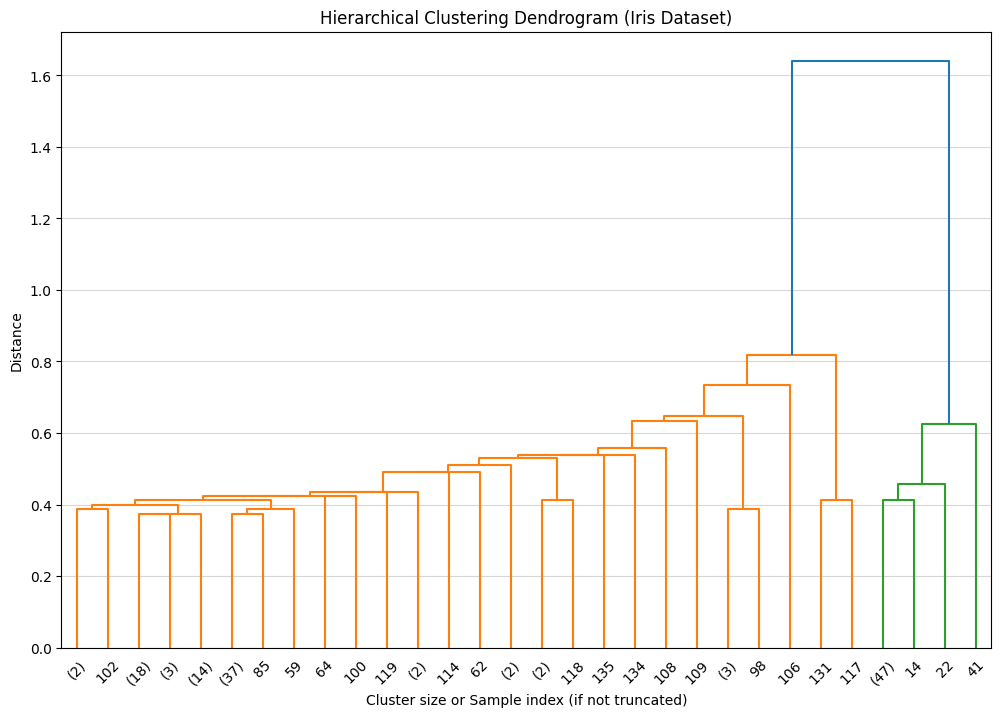

In [ ]:
from ucimlrepo import fetch_ucirepo
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
import pandas as pd

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features

# 3. Perform Hierarchical Clustering
# 'single' linkage is used as per your first code block (linked = linkage(X, 'single'))
linked = linkage(X, 'single')

# NOTE on Labels: Since the Iris dataset has 150 samples, and the original code used
# `labelList = range(1, 11)` (only 10 labels), we must omit the `labels` parameter
# to avoid an error, especially when using truncation.

# 4. Plot the Dendrogram with best parameters
# We are combining parameters from both your requests:
# - linkage matrix 'linked'
# - p=30 and truncate_mode='lastp' (from the second block) to show the last 30 merged clusters
# - orientation='top', distance_sort='descending', show_leaf_counts=True (from the first block)

plt.figure(figsize=(12, 8)) # Adjusted figure size for better visibility

dendrogram(
    linked,
    p=30,                     # Show the last 30 merged clusters
    truncate_mode='lastp',    # Truncation mode
    orientation='top',        # Orientation
    distance_sort='descending',
    show_leaf_counts=True     # Show number of original samples in each leaf
)

plt.title('Hierarchical Clustering Dendrogram (Iris Dataset)')
plt.xlabel('Cluster size or Sample index (if not truncated)')
plt.ylabel('Distance')
plt.grid(axis='y', alpha=0.5)
plt.show()


# ***Hierarchical Clustering Dendrogram of Wine Dataset***

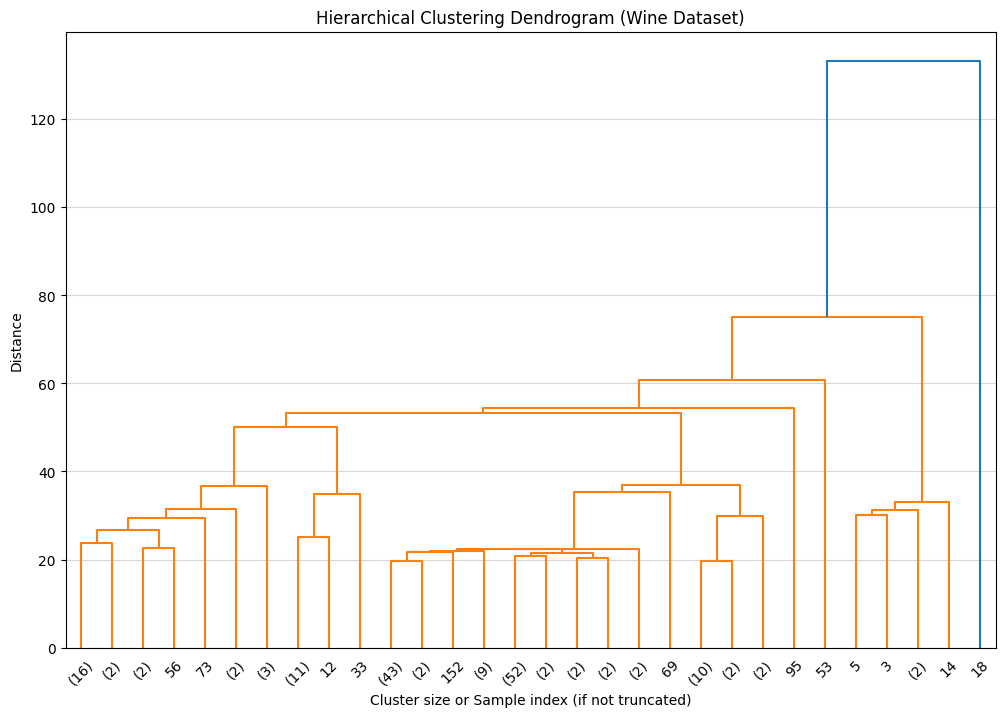

In [ ]:
from ucimlrepo import fetch_ucirepo
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
import pandas as pd

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
Xw = wine.data.features

# 3. Perform Hierarchical Clustering
# 'single' linkage is used as per your first code block (linked = linkage(X, 'single'))
linked = linkage(Xw, 'single')

# NOTE on Labels: Since the Iris dataset has 150 samples, and the original code used
# `labelList = range(1, 11)` (only 10 labels), we must omit the `labels` parameter
# to avoid an error, especially when using truncation.

# 4. Plot the Dendrogram with best parameters
# We are combining parameters from both your requests:
# - linkage matrix 'linked'
# - p=30 and truncate_mode='lastp' (from the second block) to show the last 30 merged clusters
# - orientation='top', distance_sort='descending', show_leaf_counts=True (from the first block)

plt.figure(figsize=(12, 8)) # Adjusted figure size for better visibility

dendrogram(
    linked,
    p=30,                     # Show the last 30 merged clusters
    truncate_mode='lastp',    # Truncation mode
    orientation='top',        # Orientation
    distance_sort='descending',
    show_leaf_counts=True     # Show number of original samples in each leaf
)

plt.title('Hierarchical Clustering Dendrogram (Wine Dataset)')
plt.xlabel('Cluster size or Sample index (if not truncated)')
plt.ylabel('Distance')
plt.grid(axis='y', alpha=0.5)
plt.show()


# ***DBSCAN Clustering in Iris Dataset***

DBSCAN Clustering Results:
Cluster Labels (first 20):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Estimated number of clusters: 2
Estimated number of noise points: 17


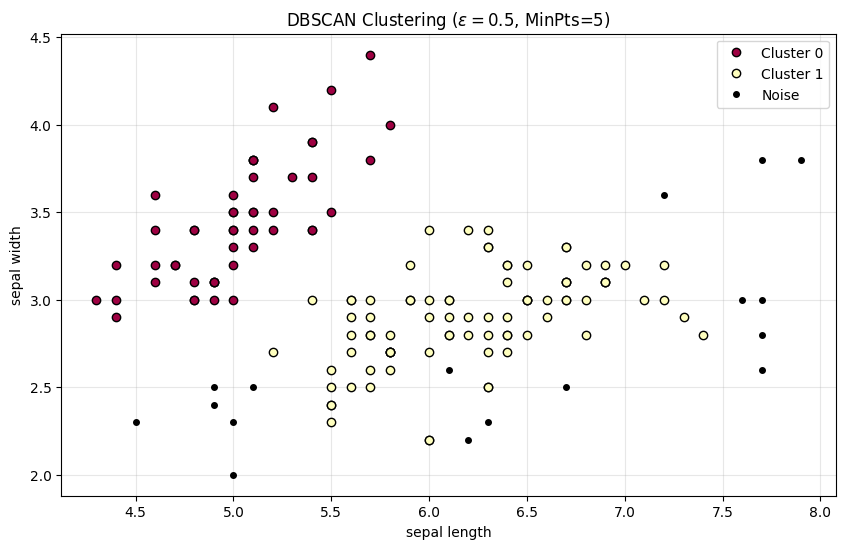

In [ ]:
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN # Changed import to DBSCAN
import pandas as pd
import numpy as np

# 1. Fetch dataset
# The Iris dataset has 150 samples and 3 known classes.
iris = fetch_ucirepo(id=53)

# 2. Prepare data
X = iris.data.features

# --- DBSCAN CLUSTERING (sklearn) and Visualization ---

# 3. Perform DBSCAN Clustering
# Parameters used: eps=0.5 and min_samples=5, as suggested by the provided function signature.
# DBSCAN finds clusters based on density and labels outliers as -1.
dbscan = DBSCAN(eps=0.5, min_samples=5)
# Note: DBSCAN does not have a predict method, so we use fit_predict directly.
cluster_labels = dbscan.fit_predict(X)

print("DBSCAN Clustering Results:")
# Display the cluster labels (first 20 for brevity)
print("Cluster Labels (first 20):")
print(cluster_labels[:20])

# Count the number of unique clusters found (excluding noise/outliers, labeled -1)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"\nEstimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# 4. Plot the results in a 2D scatter plot
# We plot the first two features (Sepal Length and Sepal Width) for visualization.
# We convert X to a numpy array for easy indexing.
X_np = X.to_numpy()

plt.figure(figsize=(10, 6))
# DBSCAN requires a list of unique labels for coloring
unique_labels = set(cluster_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    # Get mask for points belonging to the current cluster k
    class_member_mask = (cluster_labels == k)

    xy = X_np[class_member_mask]

    # Plot points
    plt.plot(
        xy[:, 0],               # Sepal Length (Feature 1)
        xy[:, 1],               # Sepal Width (Feature 2)
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=6 if k != -1 else 4, # Smaller marker for noise
        label=f'Cluster {k}' if k != -1 else 'Noise'
    )

# FIX: Changed to a raw string (r'...') to prevent Python from interpreting '\e' as an escape sequence.
plt.title(r'DBSCAN Clustering ($\epsilon=0.5$, MinPts=5)')
plt.xlabel(iris.variables.loc[0, 'name']) # Sepal Length
plt.ylabel(iris.variables.loc[1, 'name']) # Sepal Width
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ***DBSCAN Clustering in Wine Dataset***

DBSCAN Clustering Results:
Cluster Labels (first 20):
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]

Estimated number of clusters: 0
Estimated number of noise points: 178


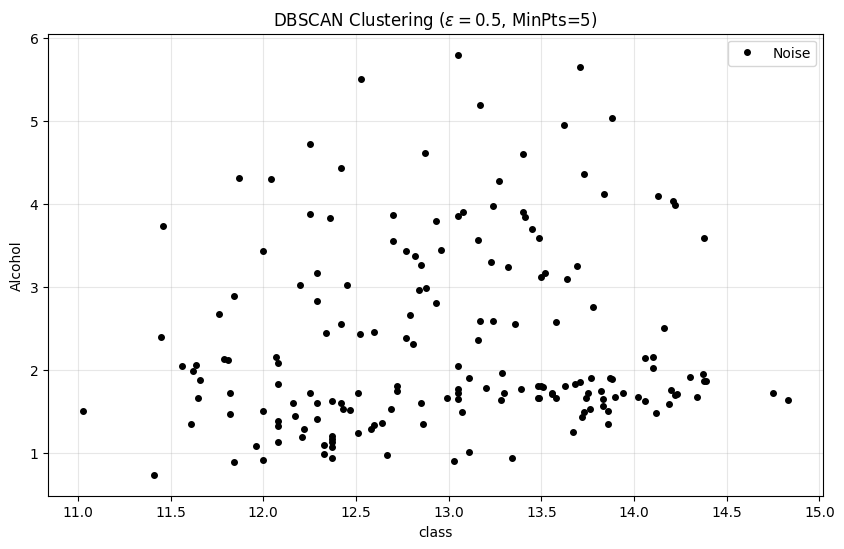

In [ ]:
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN # Changed import to DBSCAN
import pandas as pd
import numpy as np

# 1. Fetch dataset
wine = fetch_ucirepo(id=109)

# 2. Prepare data
Xw = wine.data.features

# --- DBSCAN CLUSTERING (sklearn) and Visualization ---

# 3. Perform DBSCAN Clustering
# Parameters used: eps=0.5 and min_samples=5, as suggested by the provided function signature.
# DBSCAN finds clusters based on density and labels outliers as -1.
dbscan = DBSCAN(eps=0.5, min_samples=5)
# Note: DBSCAN does not have a predict method, so we use fit_predict directly.
cluster_labels = dbscan.fit_predict(Xw)

print("DBSCAN Clustering Results:")
# Display the cluster labels (first 20 for brevity)
print("Cluster Labels (first 20):")
print(cluster_labels[:20])

# Count the number of unique clusters found (excluding noise/outliers, labeled -1)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"\nEstimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# 4. Plot the results in a 2D scatter plot
# We plot the first two features (Sepal Length and Sepal Width) for visualization.
# We convert X to a numpy array for easy indexing.
Xw_np = Xw.to_numpy()

plt.figure(figsize=(10, 6))
# DBSCAN requires a list of unique labels for coloring
unique_labels = set(cluster_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    # Get mask for points belonging to the current cluster k
    class_member_mask = (cluster_labels == k)

    xy = Xw_np[class_member_mask]

    # Plot points
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=6 if k != -1 else 4, # Smaller marker for noise
        label=f'Cluster {k}' if k != -1 else 'Noise'
    )

# FIX: Changed to a raw string (r'...') to prevent Python from interpreting '\e' as an escape sequence.
plt.title(r'DBSCAN Clustering ($\epsilon=0.5$, MinPts=5)')
plt.xlabel(wine.variables.loc[0, 'name'])
plt.ylabel(wine.variables.loc[1, 'name'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ***OPTICS Clustering on Iris Dataset***

OPTICS Clustering Results (Iris Dataset):
Cluster Labels (first 20):
[ 0  1  1  1  0 -1  1  0  1  1  0  0  1 -1 -1 -1 -1  0 -1  0]

Estimated number of clusters: 6
Estimated number of noise points: 75


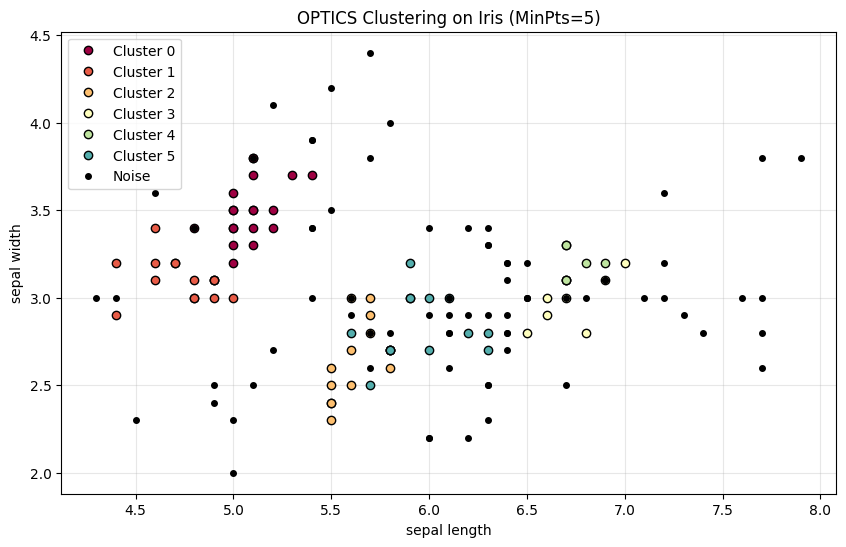

In [ ]:
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.cluster import OPTICS # Changed import to OPTICS
import pandas as pd
import numpy as np

# 1. Fetch dataset
# Reverting to the Iris dataset (id=53) as requested.
iris = fetch_ucirepo(id=53)

# 2. Prepare data
X = iris.data.features # X now holds the features of the Iris dataset

# --- OPTICS CLUSTERING (sklearn) and Visualization ---

# 3. Perform OPTICS Clustering
# Parameters used: min_samples=5 (default/suggested). OPTICS identifies
# the density-based clustering structure.
optics = OPTICS(min_samples=5)
optics.fit(X)

# OPTICS labels are stored in the .labels_ attribute after fitting.
cluster_labels = optics.labels_

print("OPTICS Clustering Results (Iris Dataset):")
# Display the cluster labels (first 20 for brevity)
print("Cluster Labels (first 20):")
print(cluster_labels[:20])

# Count the number of unique clusters found (excluding noise/outliers, labeled -1)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"\nEstimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# 4. Plot the results in a 2D scatter plot
# We plot the first two features (Sepal Length and Sepal Width) for visualization.
# We convert X to a numpy array for easy indexing.
X_np = X.to_numpy()

plt.figure(figsize=(10, 6))
# OPTICS requires a list of unique labels for coloring
unique_labels = set(cluster_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    # Get mask for points belonging to the current cluster k
    class_member_mask = (cluster_labels == k)

    xy = X_np[class_member_mask]

    # Plot points
    plt.plot(
        xy[:, 0],               # Feature 0 (Sepal Length)
        xy[:, 1],               # Feature 1 (Sepal Width)
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=6 if k != -1 else 4, # Smaller marker for noise
        label=f'Cluster {k}' if k != -1 else 'Noise'
    )

# The variable information for Iris starts at index 0.
plt.title(r'OPTICS Clustering on Iris (MinPts=5)')
plt.xlabel(iris.variables.loc[0, 'name']) # Sepal Length
plt.ylabel(iris.variables.loc[1, 'name']) # Sepal Width
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ***OPTICS Clustering on Wine Dataset***

OPTICS Clustering Results (Wine Dataset):
Cluster Labels (first 20):
[ 0  0 -1 12 -1 12  1  1  0  0 12  1  1  0 12  1  1  0 12 -1]

Estimated number of clusters: 13
Estimated number of noise points: 66


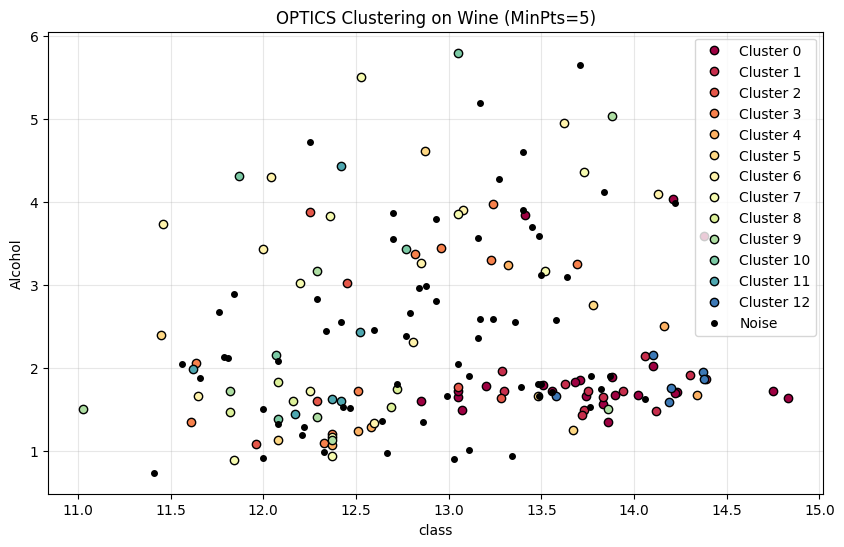

In [ ]:
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.cluster import OPTICS # Changed import to OPTICS
import pandas as pd
import numpy as np

# 1. Fetch dataset
# Now fetching the Wine dataset (id=109).
wine = fetch_ucirepo(id=109)

# 2. Prepare data
# Storing Wine features in Xw as requested.
Xw = wine.data.features

# --- OPTICS CLUSTERING (sklearn) and Visualization ---

# 3. Perform OPTICS Clustering
# Parameters used: min_samples=5 (default/suggested). OPTICS identifies
# the density-based clustering structure.
optics = OPTICS(min_samples=5)
# Fit the model to the Wine data (Xw)
optics.fit(Xw)

# OPTICS labels are stored in the .labels_ attribute after fitting.
cluster_labels = optics.labels_

print("OPTICS Clustering Results (Wine Dataset):")
# Display the cluster labels (first 20 for brevity)
print("Cluster Labels (first 20):")
print(cluster_labels[:20])

# Count the number of unique clusters found (excluding noise/outliers, labeled -1)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"\nEstimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# 4. Plot the results in a 2D scatter plot
# We plot the first two features (Alcohol and Malic Acid) for visualization.
# We convert Xw to a numpy array for easy indexing.
X_np = Xw.to_numpy()

plt.figure(figsize=(10, 6))
# OPTICS requires a list of unique labels for coloring
unique_labels = set(cluster_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    # Get mask for points belonging to the current cluster k
    class_member_mask = (cluster_labels == k)

    xy = X_np[class_member_mask]

    # Plot points
    plt.plot(
        xy[:, 0],               # Feature 0 (Alcohol)
        xy[:, 1],               # Feature 1 (Malic Acid)
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=6 if k != -1 else 4, # Smaller marker for noise
        label=f'Cluster {k}' if k != -1 else 'Noise'
    )

# The variable information for Wine starts at index 0.
plt.title(r'OPTICS Clustering on Wine (MinPts=5)')
plt.xlabel(wine.variables.loc[0, 'name']) # Alcohol
plt.ylabel(wine.variables.loc[1, 'name']) # Malic Acid
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ***K-Means++ Clustering on Iris Dataset***

--- K-MEANS++ CLUSTERING (sklearn) ---
K-Means++ Clustering Results (Iris Dataset):
Cluster Labels (first 20):
[6 1 1 1 6 6 1 1 1 1 6 1 1 1 6 6 6 6 6 6]


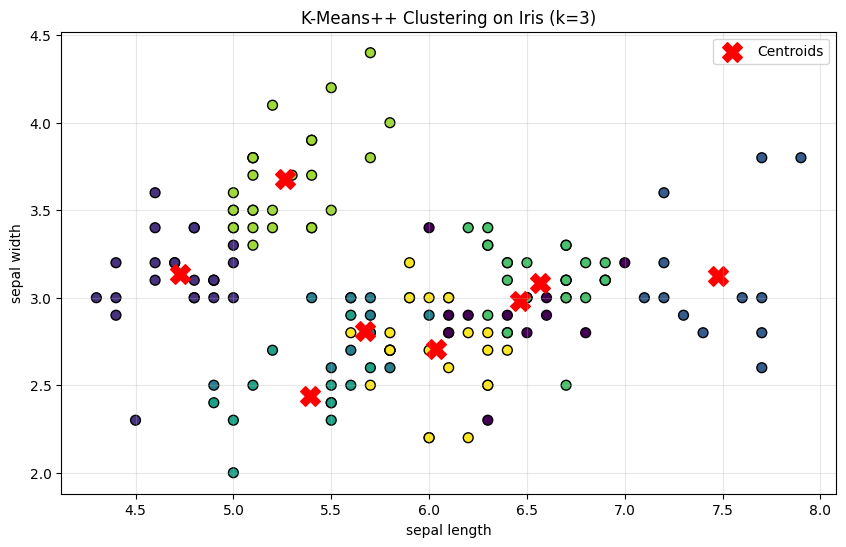

In [ ]:
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# 1. Fetch dataset
# Loading the Iris dataset (id=53).
iris = fetch_ucirepo(id=53)

# 2. Prepare data
X = iris.data.features
X_np = X.to_numpy()


# --- K-MEANS++ CLUSTERING and Visualization ---
print("--- K-MEANS++ CLUSTERING (sklearn) ---")

# 3. Perform K-Means++ Clustering
# n_clusters=3 for the three known Iris classes.
# init='k-means++' specifies the smart initialization method.
# n_init='auto' complies with modern sklearn versions.
kmeans_pp = KMeans(n_clusters=8, init='k-means++', random_state=42, n_init='auto')
cluster_labels_kmpp = kmeans_pp.fit_predict(X)

print("K-Means++ Clustering Results (Iris Dataset):")
print("Cluster Labels (first 20):")
print(cluster_labels_kmpp[:20])

# 4. Plot the results in a 2D scatter plot
# We plot the first two features (Sepal Length and Sepal Width) for visualization.
plt.figure(figsize=(10, 6))
plt.scatter(
    X_np[:, 0],               # Feature 0 (Sepal Length)
    X_np[:, 1],               # Feature 1 (Sepal Width)
    c=cluster_labels_kmpp,    # Color based on cluster labels
    cmap='viridis',           # Use a distinct color map
    edgecolor='k',
    s=50
)
# Plot the cluster centers (Centroids)
plt.scatter(
    kmeans_pp.cluster_centers_[:, 0],
    kmeans_pp.cluster_centers_[:, 1],
    marker='X',
    s=200,
    c='red',
    label='Centroids'
)

# The variable information for Iris starts at index 0.
plt.title('K-Means++ Clustering on Iris (k=3)')
plt.xlabel(iris.variables.loc[0, 'name']) # Sepal Length
plt.ylabel(iris.variables.loc[1, 'name']) # Sepal Width
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ***K-Means++ Clustering on Wine Dataset***

--- K-MEANS++ CLUSTERING (sklearn) ---
K-Means++ Clustering Results (Wine Dataset):
Cluster Labels (first 20):
[1 1 4 3 2 3 4 4 1 1 3 4 4 1 3 4 4 1 3 2]


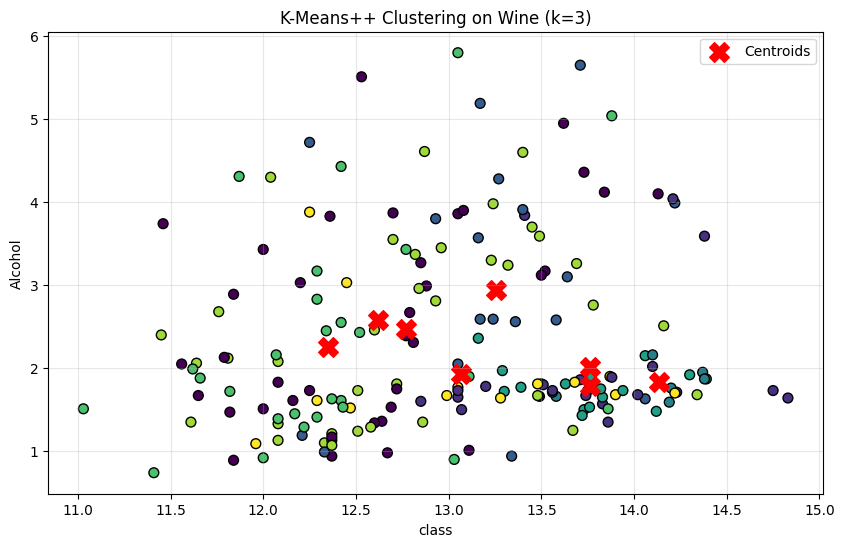

In [ ]:
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# 1. Fetch dataset
# Loading the Wine dataset (id=109).
wine = fetch_ucirepo(id=109)

# 2. Prepare data
Xw = wine.data.features
Xw_np = Xw.to_numpy()


# --- K-MEANS++ CLUSTERING and Visualization ---
print("--- K-MEANS++ CLUSTERING (sklearn) ---")

# 3. Perform K-Means++ Clustering
# n_clusters=3 for the three known Wine classes.
# init='k-means++' specifies the smart initialization method.
# n_init='auto' is used for modern scikit-learn versions.
kmeans_pp = KMeans(n_clusters=8, init='k-means++', random_state=42, n_init='auto')
cluster_labels_kmpp = kmeans_pp.fit_predict(Xw)

print("K-Means++ Clustering Results (Wine Dataset):")
print("Cluster Labels (first 20):")
print(cluster_labels_kmpp[:20])

# 4. Plot the results in a 2D scatter plot
# We plot the first two features (Alcohol and Malic Acid) for visualization.
plt.figure(figsize=(10, 6))
plt.scatter(
    Xw_np[:, 0],               # Feature 0 (Alcohol)
    Xw_np[:, 1],               # Feature 1 (Malic Acid)
    c=cluster_labels_kmpp,     # Color based on cluster labels
    cmap='viridis',            # Use a distinct color map
    edgecolor='k',
    s=50
)
# Plot the cluster centers (Centroids)
plt.scatter(
    kmeans_pp.cluster_centers_[:, 0],
    kmeans_pp.cluster_centers_[:, 1],
    marker='X',
    s=200,
    c='red',
    label='Centroids'
)

# The variable information for Wine starts at index 0.
plt.title('K-Means++ Clustering on Wine (k=3)')
plt.xlabel(wine.variables.loc[0, 'name']) # Alcohol
plt.ylabel(wine.variables.loc[1, 'name']) # Malic Acid
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ***Bisecting K-Means Clustering on Iris Dataset***

--- BISECTING K-MEANS CLUSTERING (sklearn) ---
Bisecting K-Means Clustering Results (Iris Dataset):
Cluster Labels (first 20):
[1 2 2 2 1 1 2 1 2 2 1 2 2 2 1 1 1 1 1 1]


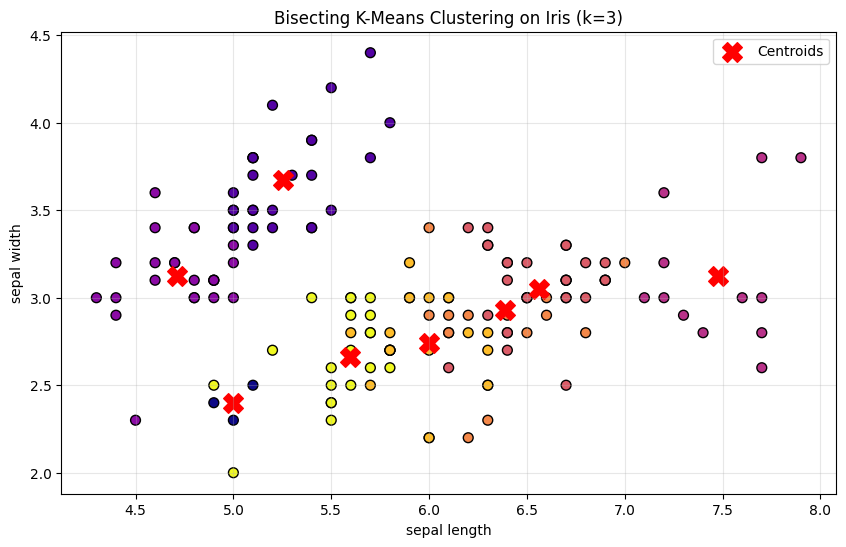

In [ ]:
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.cluster import BisectingKMeans
import pandas as pd
import numpy as np

# 1. Fetch dataset
# Loading the Iris dataset (id=53).
iris = fetch_ucirepo(id=53)

# 2. Prepare data
X = iris.data.features
X_np = X.to_numpy()


# --- BISECTING K-MEANS CLUSTERING and Visualization ---
print("--- BISECTING K-MEANS CLUSTERING (sklearn) ---")

# 3. Perform Bisecting K-Means Clustering
# n_clusters=3 for the three known Iris classes.
# Bisecting K-Means performs hierarchical splitting to achieve the target number of clusters.
# FIX: Changed n_init='auto' to n_init=10 to resolve InvalidParameterError.
bkm = BisectingKMeans(n_clusters=8, random_state=42, n_init=10)
cluster_labels_bkm = bkm.fit_predict(X)

print("Bisecting K-Means Clustering Results (Iris Dataset):")
print("Cluster Labels (first 20):")
print(cluster_labels_bkm[:20])

# 4. Plot the results in a 2D scatter plot
# We plot the first two features (Sepal Length and Sepal Width) for visualization.
plt.figure(figsize=(10, 6))
plt.scatter(
    X_np[:, 0],               # Feature 0 (Sepal Length)
    X_np[:, 1],               # Feature 1 (Sepal Width)
    c=cluster_labels_bkm,     # Color based on cluster labels
    cmap='plasma',            # Use a different color map for contrast
    edgecolor='k',
    s=50
)
# Plot the cluster centers (Centroids)
plt.scatter(
    bkm.cluster_centers_[:, 0],
    bkm.cluster_centers_[:, 1],
    marker='X',
    s=200,
    c='red',
    label='Centroids'
)

# The variable information for Iris starts at index 0.
plt.title('Bisecting K-Means Clustering on Iris (k=3)')
plt.xlabel(iris.variables.loc[0, 'name']) # Sepal Length
plt.ylabel(iris.variables.loc[1, 'name']) # Sepal Width
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ***Bisecting K-Means Clustering on Wine Dataset***

--- BISECTING K-MEANS CLUSTERING (sklearn) ---
Bisecting K-Means Clustering Results (Wine Dataset):
Cluster Labels (first 20):
[7 7 4 5 2 5 4 4 7 7 5 4 4 7 5 4 4 7 5 2]


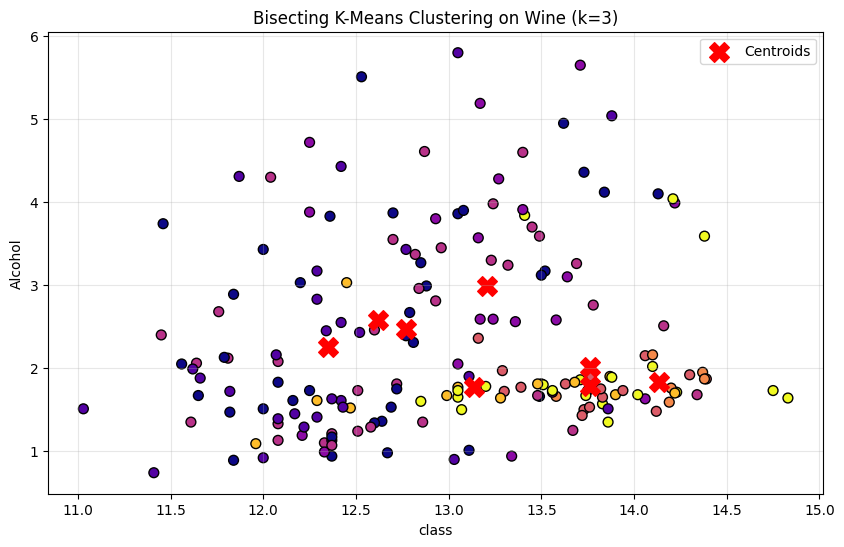

In [ ]:
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.cluster import BisectingKMeans
import pandas as pd
import numpy as np

# 1. Fetch dataset
# Loading the Wine dataset (id=109).
wine = fetch_ucirepo(id=109)

# 2. Prepare data
Xw = wine.data.features
Xw_np = Xw.to_numpy()


# --- BISECTING K-MEANS CLUSTERING and Visualization ---
print("--- BISECTING K-MEANS CLUSTERING (sklearn) ---")

# 3. Perform Bisecting K-Means Clustering
# n_clusters=3 for the three known Wine classes.
# Bisecting K-Means performs hierarchical splitting to achieve the target number of clusters.
# n_init=10 is used to avoid errors in some sklearn versions.
bkm = BisectingKMeans(n_clusters=8, random_state=42, n_init=10)
cluster_labels_bkm = bkm.fit_predict(Xw)

print("Bisecting K-Means Clustering Results (Wine Dataset):")
print("Cluster Labels (first 20):")
print(cluster_labels_bkm[:20])

# 4. Plot the results in a 2D scatter plot
# We plot the first two features (Alcohol and Malic Acid) for visualization.
plt.figure(figsize=(10, 6))
plt.scatter(
    Xw_np[:, 0],               # Feature 0 (Alcohol)
    Xw_np[:, 1],               # Feature 1 (Malic Acid)
    c=cluster_labels_bkm,      # Color based on cluster labels
    cmap='plasma',             # Use a distinct color map
    edgecolor='k',
    s=50
)
# Plot the cluster centers (Centroids)
plt.scatter(
    bkm.cluster_centers_[:, 0],
    bkm.cluster_centers_[:, 1],
    marker='X',
    s=200,
    c='red',
    label='Centroids'
)

# The variable information for Wine starts at index 0.
plt.title('Bisecting K-Means Clustering on Wine (k=3)')
plt.xlabel(wine.variables.loc[0, 'name']) # Alcohol
plt.ylabel(wine.variables.loc[1, 'name']) # Malic Acid
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ***Comparison of Clustering Algorithms on Iris Dataset***

Fitting K-Means...
Fitting K-Medoids (PAM)...
Fitting Agglomerative (Ward)...
Fitting DBSCAN ($\epsilon=0.5$)...
Fitting OPTICS (MinPts=5)...


/tmp/ipython-input-3197346384.py:180: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  metrics_df_formatted = metrics_df.applymap(format_float)



COMPREHENSIVE CLUSTERING PERFORMANCE COMPARISON (IRIS DATASET, K=3)

--- Performance Metrics Table ---
| Algorithm               |   Detected Clusters |   Adjusted Rand Score (ARI) |   Rand Score (RI) |   Normalized MI (NMI) |   Adjusted MI (AMI) |   Mutual Info (MI) |   Cohesion (SSE) |   Separation (SSB) |   Silhouette Coefficient |   Calinski-Harabasz Index |   Davies-Bouldin Index |
|:------------------------|--------------------:|----------------------------:|------------------:|----------------------:|--------------------:|-------------------:|-----------------:|-------------------:|-------------------------:|--------------------------:|-----------------------:|
| K-Means                 |                   8 |                      0.2926 |            0.7299 |                0.5105 |              0.4935 |             0.772  |          62.6518 |            537.348 |                   0.3404 |                   173.985 |                 0.9124 |
| K-Medoids (PAM)         |        

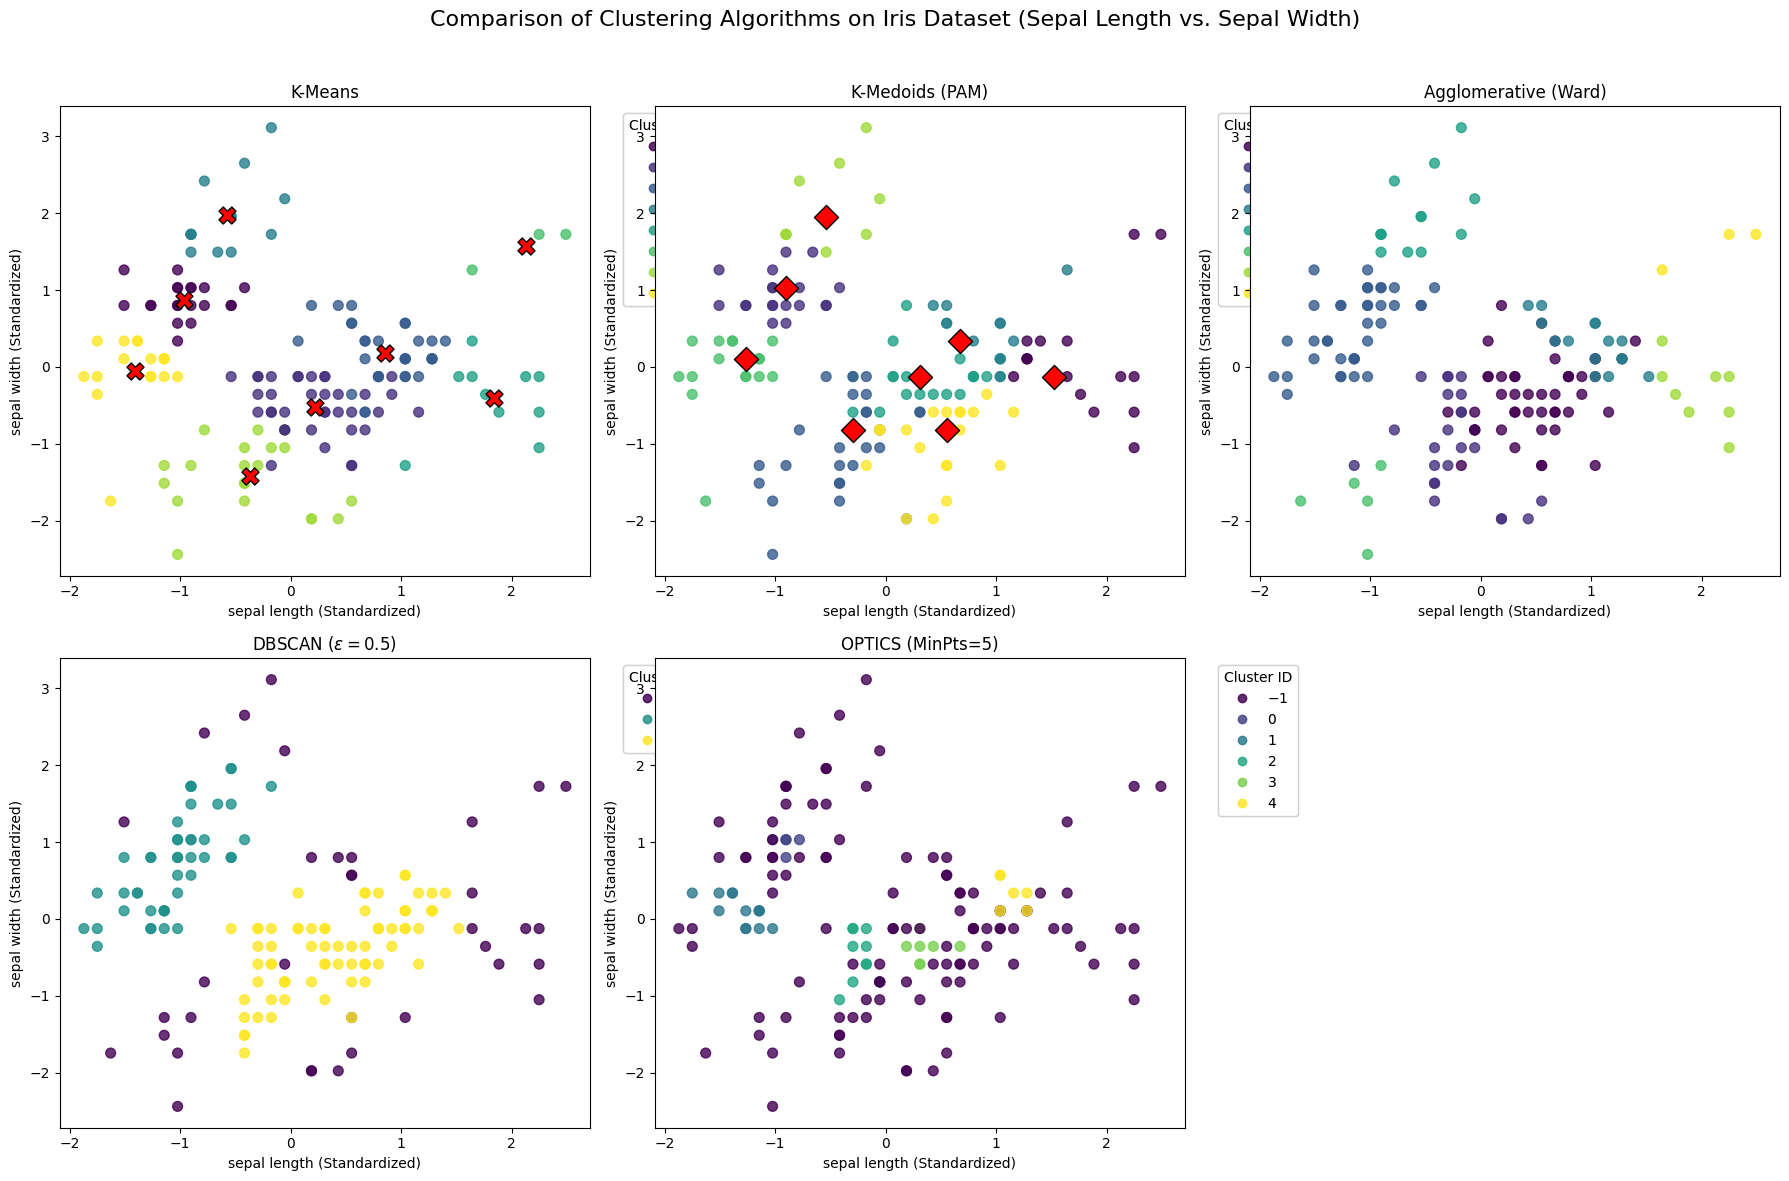

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn_extra.cluster import KMedoids # Requires pip install scikit-learn-extra
from sklearn import metrics
from matplotlib import pyplot as plt

# --- 1. DATA PREPARATION: IRIS DATASET (ID 53) ---

# Fetch dataset
iris = fetch_ucirepo(id=53)

# Data (features)
X = iris.data.features.copy()
# True class labels
y = iris.data.targets['class']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Map true class labels to numerical format 0, 1, 2...
# This is necessary for supervised evaluation metrics (Rand, MI)
true_labels = pd.factorize(y)[0]

# Set the feature names for plotting (since metadata access sometimes fails)
feature_names = X.columns.tolist()

# Define K (number of clusters) based on known true classes
N_CLUSTERS = 8

# --- 2. HELPER FUNCTION FOR COHESION AND SEPARATION (SSE/SSB) ---

def calculate_cohesion_separation(X_data, labels):
    """Calculates Sum of Squared Errors (SSE) and Sum of Squares Between groups (SSB)."""

    # Filter out noise points (labels == -1) for calculation, if applicable
    X_clustered = X_data[labels != -1]
    labels_clustered = labels[labels != -1]

    unique_clusters = np.unique(labels_clustered)

    if len(unique_clusters) == 0:
        # Cannot calculate if no clusters are found
        return np.nan, np.nan

    global_mean = np.mean(X_data, axis=0)
    sse = 0.0  # Cohesion
    ssb = 0.0  # Separation

    for k in unique_clusters:
        cluster_points = X_clustered[labels_clustered == k]

        # Ensure cluster_points is not empty before calculating mean
        if cluster_points.shape[0] == 0:
            continue

        cluster_mean = np.mean(cluster_points, axis=0)

        # Cohesion (SSE): Sum of squared distances from points to their cluster mean
        sse += np.sum(np.sum((cluster_points - cluster_mean) ** 2, axis=1))

        # Separation (SSB): Sum of squared distances from cluster mean to global mean
        nk = len(cluster_points)
        ssb += nk * np.sum((cluster_mean - global_mean) ** 2)

    return sse, ssb

# --- 3. CLUSTERING ALGORITHMS EXECUTION ---

# Dictionary to store algorithm results
algorithms = {
    'K-Means': KMeans(n_clusters=N_CLUSTERS, init='k-means++', random_state=42, n_init=10),
    'K-Medoids (PAM)': KMedoids(n_clusters=N_CLUSTERS, random_state=42, init='k-medoids++'),
    'Agglomerative (Ward)': AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward'),
    r'DBSCAN ($\epsilon=0.5$)': DBSCAN(eps=0.5, min_samples=5),
    r'OPTICS (MinPts=5)': OPTICS(min_samples=5)
}

# Dictionary to hold the final cluster labels and metrics
cluster_labels = {}
all_metrics = []

for name, algo in algorithms.items():
    print(f"Fitting {name}...")

    if name == r'OPTICS (MinPts=5)':
        # OPTICS requires fit, then labels are extracted
        algo.fit(X_scaled)
        labels = algo.labels_
    else:
        # K-Means, K-Medoids, Agglomerative, DBSCAN use fit_predict
        labels = algo.fit_predict(X_scaled)

    cluster_labels[name] = labels

    # --- METRICS COLLECTION ---
    metrics_data = {'Algorithm': name}
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

    metrics_data['Detected Clusters'] = n_clusters_

    has_valid_clusters = n_clusters_ >= 2

    # 1. SUPERVISED METRICS (Comparing to true_labels)
    try:
        metrics_data['Adjusted Rand Score (ARI)'] = metrics.adjusted_rand_score(true_labels, labels)
        metrics_data['Rand Score (RI)'] = metrics.rand_score(true_labels, labels)
        metrics_data['Normalized MI (NMI)'] = metrics.normalized_mutual_info_score(true_labels, labels)
        metrics_data['Adjusted MI (AMI)'] = metrics.adjusted_mutual_info_score(true_labels, labels)
        metrics_data['Mutual Info (MI)'] = metrics.mutual_info_score(true_labels, labels)
    except:
        metrics_data['Adjusted Rand Score (ARI)'] = np.nan
        metrics_data['Rand Score (RI)'] = np.nan
        metrics_data['Normalized MI (NMI)'] = np.nan
        metrics_data['Adjusted MI (AMI)'] = np.nan
        metrics_data['Mutual Info (MI)'] = np.nan

    # 2. UNSUPERVISED METRICS (Internal validation)
    if has_valid_clusters:
        X_internal = X_scaled[labels != -1]
        labels_internal = labels[labels != -1]

        if len(np.unique(labels_internal)) >= 2:
            try:
                metrics_data['Silhouette Coefficient'] = metrics.silhouette_score(X_internal, labels_internal)
                metrics_data['Calinski-Harabasz Index'] = metrics.calinski_harabasz_score(X_internal, labels_internal)
                metrics_data['Davies-Bouldin Index'] = metrics.davies_bouldin_score(X_internal, labels_internal)
            except:
                metrics_data['Silhouette Coefficient'] = np.nan
                metrics_data['Calinski-Harabasz Index'] = np.nan
                metrics_data['Davies-Bouldin Index'] = np.nan
        else:
            metrics_data['Silhouette Coefficient'] = np.nan
            metrics_data['Calinski-Harabasz Index'] = np.nan
            metrics_data['Davies-Bouldin Index'] = np.nan
    else:
        metrics_data['Silhouette Coefficient'] = np.nan
        metrics_data['Calinski-Harabasz Index'] = np.nan
        metrics_data['Davies-Bouldin Index'] = np.nan


    # 3. COHESION AND SEPARATION (SSE/SSB)
    sse, ssb = calculate_cohesion_separation(X_scaled, labels)
    metrics_data['Cohesion (SSE)'] = sse
    metrics_data['Separation (SSB)'] = ssb

    all_metrics.append(metrics_data)


# --- 4. TABULAR COMPARISON ---

metrics_df = pd.DataFrame(all_metrics)

# Set 'Algorithm' as the index for better presentation
metrics_df = metrics_df.set_index('Algorithm')

# Reorder columns logically
ordered_columns = [
    'Detected Clusters',
    # Supervised
    'Adjusted Rand Score (ARI)', 'Rand Score (RI)',
    'Normalized MI (NMI)', 'Adjusted MI (AMI)', 'Mutual Info (MI)',
    # Cohesion/Separation
    'Cohesion (SSE)', 'Separation (SSB)',
    # Unsupervised
    'Silhouette Coefficient', 'Calinski-Harabasz Index', 'Davies-Bouldin Index',
]

metrics_df = metrics_df[ordered_columns]

# Format float values for clear display
def format_float(x):
    if isinstance(x, (float, np.float64)) and not np.isnan(x):
        return f"{x:.4f}"
    return x

metrics_df_formatted = metrics_df.applymap(format_float)


print("\n==========================================================================================")
print("COMPREHENSIVE CLUSTERING PERFORMANCE COMPARISON (IRIS DATASET, K=3)")
print("==========================================================================================")
print("\n--- Performance Metrics Table ---")

# Print the DataFrame as a Markdown table
print(metrics_df_formatted.to_markdown())

# --- 5. VISUALIZATION (Plotting the first two features) ---

print("\n\n--- Visualization ---")

# Set up a figure for visualization of all 5 algorithms
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 grid into a 1D array for easy iteration

fig.suptitle('Comparison of Clustering Algorithms on Iris Dataset (Sepal Length vs. Sepal Width)', fontsize=16)

# The last subplot will be empty, so remove it
fig.delaxes(axes[-1])

for i, (name, labels) in enumerate(cluster_labels.items()):
    ax = axes[i]

    # Plot the data points, colored by their assigned cluster label
    # X_scaled[:, 0] is Sepal Length, X_scaled[:, 1] is Sepal Width
    scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)

    # If K-Means or K-Medoids, plot the cluster centers/medoids
    if 'K-Means' in name or 'K-Medoids' in name:
        if 'K-Means' in name:
            centers = algorithms[name].cluster_centers_
            marker = 'X'
            label = 'Centroids'
        else: # K-Medoids
            centers = algorithms[name].cluster_centers_
            marker = 'D'
            label = 'Medoids'

        ax.scatter(centers[:, 0], centers[:, 1], c='red', s=150, marker=marker, edgecolor='black', label=label)

    ax.set_title(f'{name}')
    ax.set_xlabel(f'{feature_names[0]} (Standardized)')
    ax.set_ylabel(f'{feature_names[1]} (Standardized)')

    # Add a legend for the clusters
    legend1 = ax.legend(*scatter.legend_elements(), title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.add_artist(legend1)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()

# ***Comparison of Clustering Algorithms on Wine Dataset***

Fitting K-Means...
Fitting K-Medoids (PAM)...
Fitting Agglomerative (Ward)...
Fitting DBSCAN ($\epsilon=0.5$)...
Fitting OPTICS (MinPts=5)...


/tmp/ipython-input-198062125.py:180: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  metrics_df_formatted = metrics_df.applymap(format_float)



COMPREHENSIVE CLUSTERING PERFORMANCE COMPARISON (IRIS DATASET, K=3)

--- Performance Metrics Table ---
| Algorithm               |   Detected Clusters |   Adjusted Rand Score (ARI) |   Rand Score (RI) |   Normalized MI (NMI) |   Adjusted MI (AMI) |   Mutual Info (MI) |   Cohesion (SSE) |   Separation (SSB) |   Silhouette Coefficient |   Calinski-Harabasz Index |   Davies-Bouldin Index |
|:------------------------|--------------------:|----------------------------:|------------------:|----------------------:|--------------------:|-------------------:|-----------------:|-------------------:|-------------------------:|--------------------------:|-----------------------:|
| K-Means                 |                   8 |                      0.4154 |            0.7753 |                0.5912 |              0.5795 |             0.9024 |         935.201  |           1378.8   |                   0.157  |                   35.8053 |                 1.7409 |
| K-Medoids (PAM)         |        

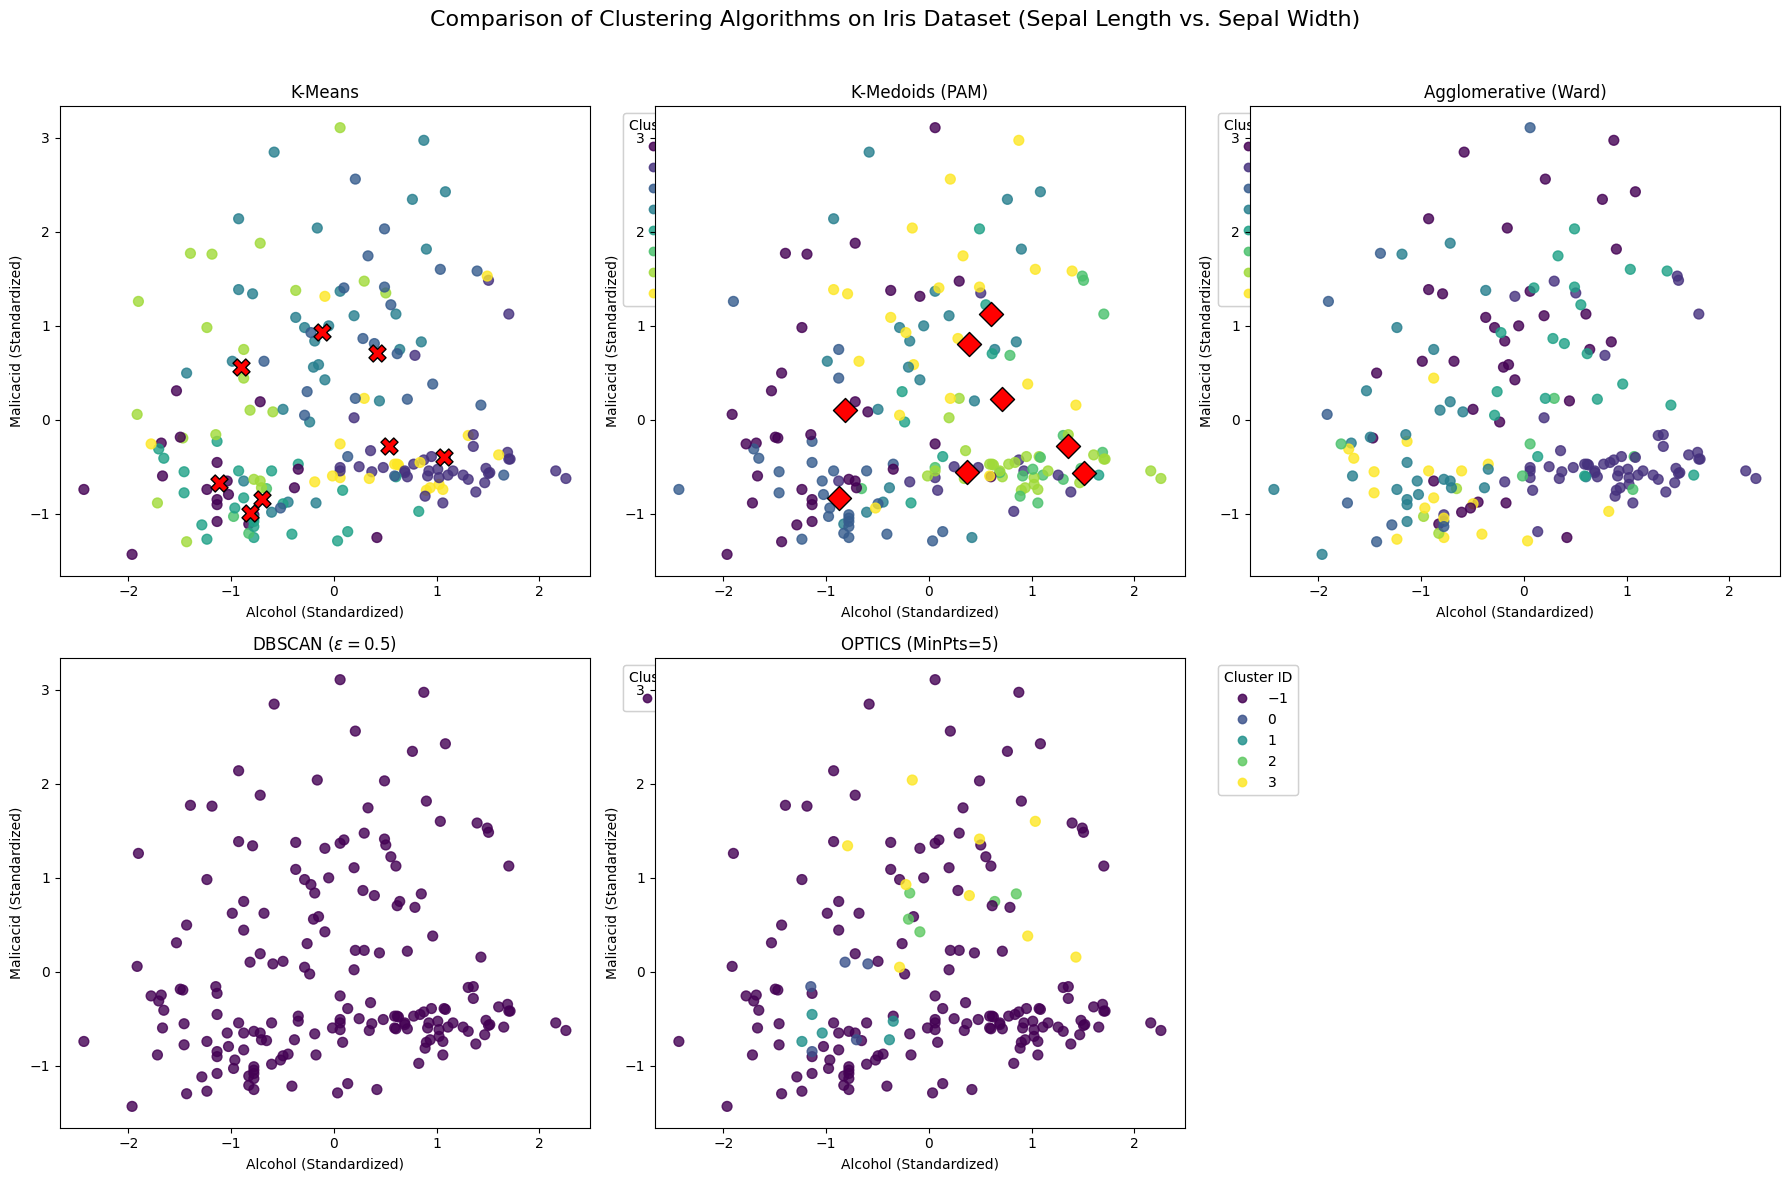

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn_extra.cluster import KMedoids # Requires pip install scikit-learn-extra
from sklearn import metrics
from matplotlib import pyplot as plt

# --- 1. DATA PREPARATION: IRIS DATASET (ID 53) ---

# Fetch dataset
wine = fetch_ucirepo(id=109)

# Data (features)
Xw = wine.data.features.copy()
# True class labels
yw = wine.data.targets['class']

# Standardize the features
scaler = StandardScaler()
Xw_scaled = scaler.fit_transform(Xw)

# Map true class labels to numerical format 0, 1, 2...
# This is necessary for supervised evaluation metrics (Rand, MI)
true_labels = pd.factorize(yw)[0]

# Set the feature names for plotting (since metadata access sometimes fails)
feature_names = Xw.columns.tolist()

# Define K (number of clusters) based on known true classes
N_CLUSTERS = 8

# --- 2. HELPER FUNCTION FOR COHESION AND SEPARATION (SSE/SSB) ---

def calculate_cohesion_separation(Xw_data, labels):
    """Calculates Sum of Squared Errors (SSE) and Sum of Squares Between groups (SSB)."""

    # Filter out noise points (labels == -1) for calculation, if applicable
    Xw_clustered = Xw_data[labels != -1]
    labels_clustered = labels[labels != -1]

    unique_clusters = np.unique(labels_clustered)

    if len(unique_clusters) == 0:
        # Cannot calculate if no clusters are found
        return np.nan, np.nan

    global_mean = np.mean(Xw_data, axis=0)
    sse = 0.0  # Cohesion
    ssb = 0.0  # Separation

    for k in unique_clusters:
        cluster_points = Xw_clustered[labels_clustered == k]

        # Ensure cluster_points is not empty before calculating mean
        if cluster_points.shape[0] == 0:
            continue

        cluster_mean = np.mean(cluster_points, axis=0)

        # Cohesion (SSE): Sum of squared distances from points to their cluster mean
        sse += np.sum(np.sum((cluster_points - cluster_mean) ** 2, axis=1))

        # Separation (SSB): Sum of squared distances from cluster mean to global mean
        nk = len(cluster_points)
        ssb += nk * np.sum((cluster_mean - global_mean) ** 2)

    return sse, ssb

# --- 3. CLUSTERING ALGORITHMS EXECUTION ---

# Dictionary to store algorithm results
algorithms = {
    'K-Means': KMeans(n_clusters=N_CLUSTERS, init='k-means++', random_state=42, n_init=10),
    'K-Medoids (PAM)': KMedoids(n_clusters=N_CLUSTERS, random_state=42, init='k-medoids++'),
    'Agglomerative (Ward)': AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward'),
    r'DBSCAN ($\epsilon=0.5$)': DBSCAN(eps=0.5, min_samples=5),
    r'OPTICS (MinPts=5)': OPTICS(min_samples=5)
}

# Dictionary to hold the final cluster labels and metrics
cluster_labels = {}
all_metrics = []

for name, algo in algorithms.items():
    print(f"Fitting {name}...")

    if name == r'OPTICS (MinPts=5)':
        # OPTICS requires fit, then labels are extracted
        algo.fit(Xw_scaled)
        labels = algo.labels_
    else:
        # K-Means, K-Medoids, Agglomerative, DBSCAN use fit_predict
        labels = algo.fit_predict(Xw_scaled)

    cluster_labels[name] = labels

    # --- METRICS COLLECTION ---
    metrics_data = {'Algorithm': name}
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

    metrics_data['Detected Clusters'] = n_clusters_

    has_valid_clusters = n_clusters_ >= 2

    # 1. SUPERVISED METRICS (Comparing to true_labels)
    try:
        metrics_data['Adjusted Rand Score (ARI)'] = metrics.adjusted_rand_score(true_labels, labels)
        metrics_data['Rand Score (RI)'] = metrics.rand_score(true_labels, labels)
        metrics_data['Normalized MI (NMI)'] = metrics.normalized_mutual_info_score(true_labels, labels)
        metrics_data['Adjusted MI (AMI)'] = metrics.adjusted_mutual_info_score(true_labels, labels)
        metrics_data['Mutual Info (MI)'] = metrics.mutual_info_score(true_labels, labels)
    except:
        metrics_data['Adjusted Rand Score (ARI)'] = np.nan
        metrics_data['Rand Score (RI)'] = np.nan
        metrics_data['Normalized MI (NMI)'] = np.nan
        metrics_data['Adjusted MI (AMI)'] = np.nan
        metrics_data['Mutual Info (MI)'] = np.nan

    # 2. UNSUPERVISED METRICS (Internal validation)
    if has_valid_clusters:
        Xw_internal = Xw_scaled[labels != -1]
        labels_internal = labels[labels != -1]

        if len(np.unique(labels_internal)) >= 2:
            try:
                metrics_data['Silhouette Coefficient'] = metrics.silhouette_score(Xw_internal, labels_internal)
                metrics_data['Calinski-Harabasz Index'] = metrics.calinski_harabasz_score(Xw_internal, labels_internal)
                metrics_data['Davies-Bouldin Index'] = metrics.davies_bouldin_score(Xw_internal, labels_internal)
            except:
                metrics_data['Silhouette Coefficient'] = np.nan
                metrics_data['Calinski-Harabasz Index'] = np.nan
                metrics_data['Davies-Bouldin Index'] = np.nan
        else:
            metrics_data['Silhouette Coefficient'] = np.nan
            metrics_data['Calinski-Harabasz Index'] = np.nan
            metrics_data['Davies-Bouldin Index'] = np.nan
    else:
        metrics_data['Silhouette Coefficient'] = np.nan
        metrics_data['Calinski-Harabasz Index'] = np.nan
        metrics_data['Davies-Bouldin Index'] = np.nan


    # 3. COHESION AND SEPARATION (SSE/SSB)
    sse, ssb = calculate_cohesion_separation(Xw_scaled, labels)
    metrics_data['Cohesion (SSE)'] = sse
    metrics_data['Separation (SSB)'] = ssb

    all_metrics.append(metrics_data)


# --- 4. TABULAR COMPARISON ---

metrics_df = pd.DataFrame(all_metrics)

# Set 'Algorithm' as the index for better presentation
metrics_df = metrics_df.set_index('Algorithm')

# Reorder columns logically
ordered_columns = [
    'Detected Clusters',
    # Supervised
    'Adjusted Rand Score (ARI)', 'Rand Score (RI)',
    'Normalized MI (NMI)', 'Adjusted MI (AMI)', 'Mutual Info (MI)',
    # Cohesion/Separation
    'Cohesion (SSE)', 'Separation (SSB)',
    # Unsupervised
    'Silhouette Coefficient', 'Calinski-Harabasz Index', 'Davies-Bouldin Index',
]

metrics_df = metrics_df[ordered_columns]

# Format float values for clear display
def format_float(x):
    if isinstance(x, (float, np.float64)) and not np.isnan(x):
        return f"{x:.4f}"
    return x

metrics_df_formatted = metrics_df.applymap(format_float)


print("\n==========================================================================================")
print("COMPREHENSIVE CLUSTERING PERFORMANCE COMPARISON (IRIS DATASET, K=3)")
print("==========================================================================================")
print("\n--- Performance Metrics Table ---")

# Print the DataFrame as a Markdown table
print(metrics_df_formatted.to_markdown())

# --- 5. VISUALIZATION (Plotting the first two features) ---

print("\n\n--- Visualization ---")

# Set up a figure for visualization of all 5 algorithms
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 grid into a 1D array for easy iteration

fig.suptitle('Comparison of Clustering Algorithms on Iris Dataset (Sepal Length vs. Sepal Width)', fontsize=16)

# The last subplot will be empty, so remove it
fig.delaxes(axes[-1])

for i, (name, labels) in enumerate(cluster_labels.items()):
    ax = axes[i]

    # Plot the data points, colored by their assigned cluster label
    # X_scaled[:, 0] is Sepal Length, X_scaled[:, 1] is Sepal Width
    scatter = ax.scatter(Xw_scaled[:, 0], Xw_scaled[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)

    # If K-Means or K-Medoids, plot the cluster centers/medoids
    if 'K-Means' in name or 'K-Medoids' in name:
        if 'K-Means' in name:
            centers = algorithms[name].cluster_centers_
            marker = 'X'
            label = 'Centroids'
        else: # K-Medoids
            centers = algorithms[name].cluster_centers_
            marker = 'D'
            label = 'Medoids'

        ax.scatter(centers[:, 0], centers[:, 1], c='red', s=150, marker=marker, edgecolor='black', label=label)

    ax.set_title(f'{name}')
    ax.set_xlabel(f'{feature_names[0]} (Standardized)')
    ax.set_ylabel(f'{feature_names[1]} (Standardized)')

    # Add a legend for the clusters
    legend1 = ax.legend(*scatter.legend_elements(), title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.add_artist(legend1)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()